In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SHAPEFILE = "../dashboard_alerts-shapefile/dashboard_alerts_shapefile.shp"

gdf = gpd.read_file(SHAPEFILE)

print("\n=== BASIC INFO ===")
print(gdf.head())
print("\nColumns:")
print(gdf.columns.tolist())
print("\nShape:")
print(gdf.shape)
print("\nCRS:")
print(gdf.crs)

#gdf.plot(figsize=(10, 10),edgecolor='black')


=== BASIC INFO ===
   codealerta                    fonte                                biome  \
0    40003279  {GAIA,GLAD-S,LUCA,RADD}                             Amazonía   
1    40006753                  {IDEAM}  Bosque húmedo tropical del Pacífico   
2    40006776                  {IDEAM}  Bosque húmedo tropical del Pacífico   
3    40006777             {IDEAM,RADD}  Bosque húmedo tropical del Pacífico   
4    40006798                  {IDEAM}  Bosque húmedo tropical del Pacífico   

  department         municipali         watershedl   regions    raisglimit  \
0       Meta        La Macarena        La Macarena  Amazonia  Límite RAISG   
1      Chocó  Carmen del Darién  Carmen del Darién  Pacifico           NaN   
2      Cauca              Guapi              Guapi  Pacifico           NaN   
3      Chocó           Ríosucio           Ríosucio  Pacifico           NaN   
4      Chocó  Carmen del Darién  Carmen del Darién  Pacifico           NaN   

  indigenous                        

<DatetimeArray>
['2025-03-31 00:00:00', '2020-03-31 00:00:00', '2020-06-30 00:00:00',
 '2020-09-30 00:00:00', '2020-12-31 00:00:00', '2021-03-31 00:00:00',
 '2021-06-30 00:00:00', '2021-09-30 00:00:00', '2021-12-31 00:00:00',
 '2022-03-31 00:00:00',
 ...
 '2026-01-31 00:00:00', '2026-02-11 00:00:00', '2026-02-17 00:00:00',
 '2026-01-12 00:00:00', '2026-02-08 00:00:00', '2026-01-15 00:00:00',
 '2026-02-05 00:00:00', '2026-02-26 00:00:00', '2026-02-04 00:00:00',
 '2026-02-23 00:00:00']
Length: 390, dtype: datetime64[us]


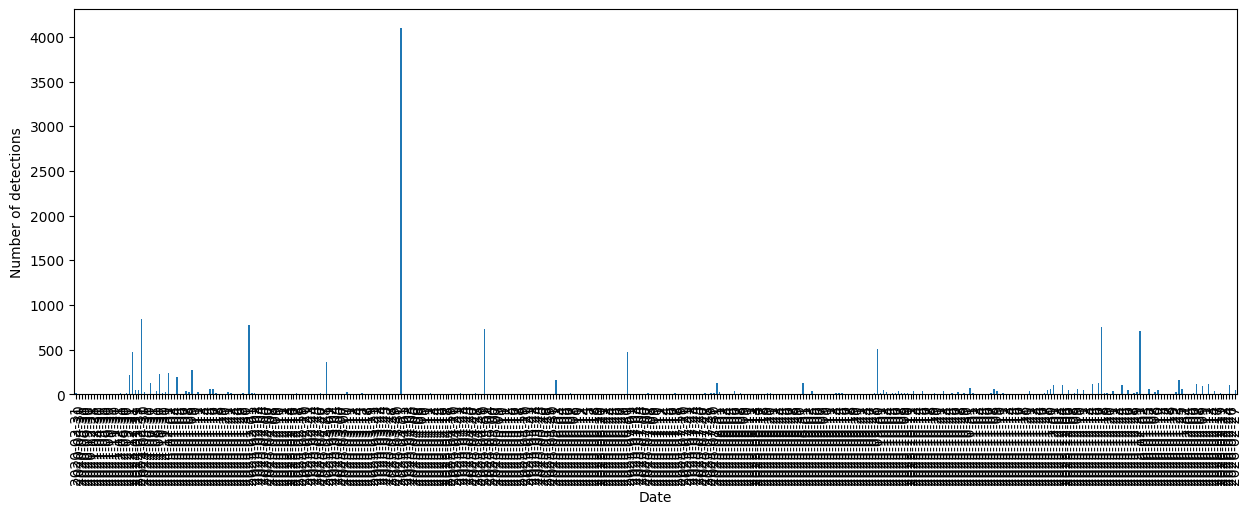

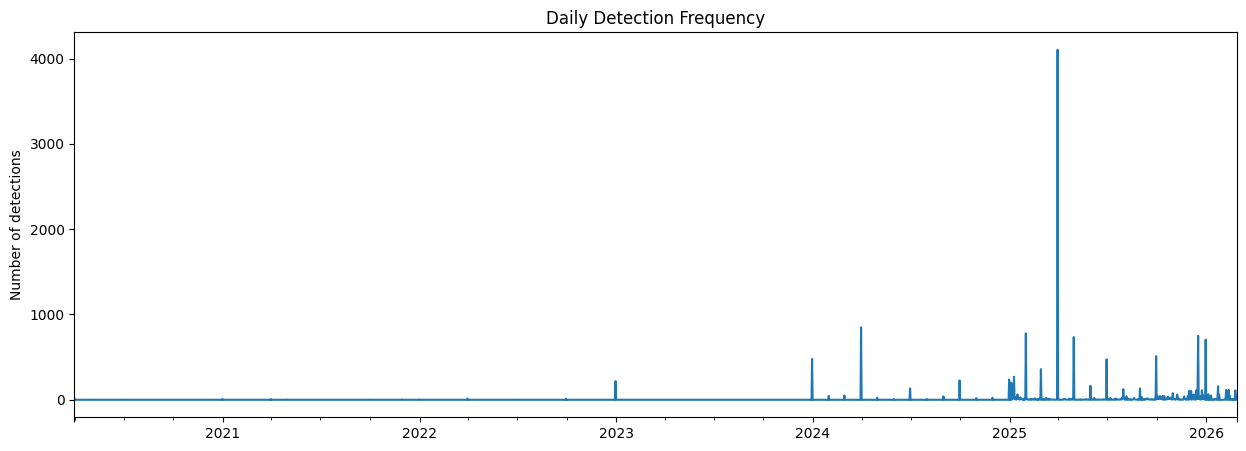

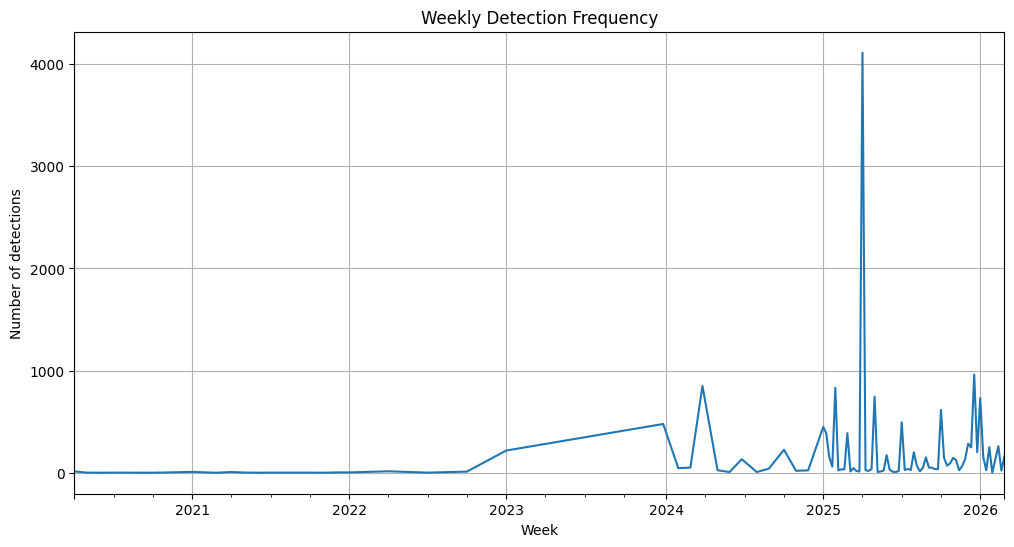

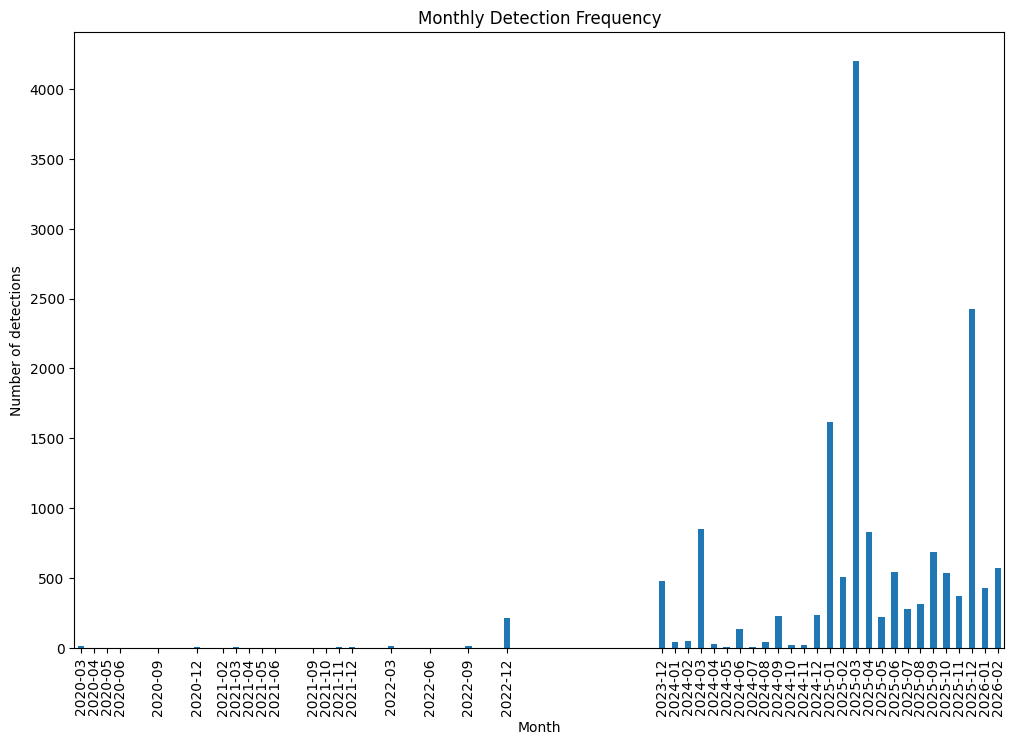

In [3]:
gdf["datadetec"] = pd.to_datetime(gdf["datadetec"])

date_counts = gdf["datadetec"].value_counts().sort_index()

print(gdf["datadetec"].unique())

all_dates = pd.date_range(
    start=gdf["datadetec"].min(),
    end=gdf["datadetec"].max(),
    freq="D"
)

daily_counts = date_counts.reindex(all_dates, fill_value=0)

date_counts.index = date_counts.index.strftime("%Y-%m-%d")

plt.figure(figsize=(15, 5))
date_counts.plot(kind="bar")
plt.ylabel("Number of detections")
plt.xlabel("Date")
plt.show()

plt.figure(figsize=(15, 5))
daily_counts.plot()
plt.ylabel("Number of detections")
plt.title("Daily Detection Frequency")
plt.show()

#weekly_counts = daily_counts.resample("W").sum()
weekly_counts = (
    gdf.groupby(
        gdf["datadetec"].dt.to_period("W")
    )
    .size()
)
#print(weekly_counts)

plt.figure(figsize=(12, 6))
weekly_counts.plot()
plt.xlabel("Week")
plt.ylabel("Number of detections")
plt.title("Weekly Detection Frequency")
plt.grid(True)
plt.show()

monthly_counts = (
    gdf.groupby(
        gdf["datadetec"].dt.to_period("M")
    )
    .size()
)

plt.figure(figsize=(12, 8))
monthly_counts.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of detections")
plt.title("Monthly Detection Frequency")
plt.show()

<StringArray>
['GAIA', 'GLAD-S', 'LUCA', 'RADD', 'IDEAM', 'JJ-FAST', 'GLAD-L', 'DIST']
Length: 8, dtype: str
fonte
DIST        246
GAIA       2575
GLAD-L     3887
GLAD-S     7284
IDEAM      9874
JJ-FAST     288
LUCA       4332
RADD       3440
Name: count, dtype: int64


Text(0.5, 0, 'Source')

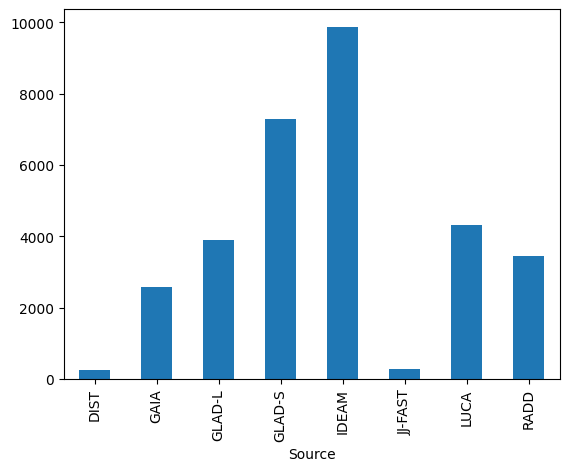

In [4]:
gdf["fonte"] = (
    gdf["fonte"]
	.str.strip("{}")
	.str.split(",")
)
print(gdf["fonte"].explode().unique())

counts = (
    gdf["fonte"]
    .explode()
    .value_counts()
    .sort_index()
)

print(counts)

counts.plot(kind="bar")
plt.xlabel("Source")

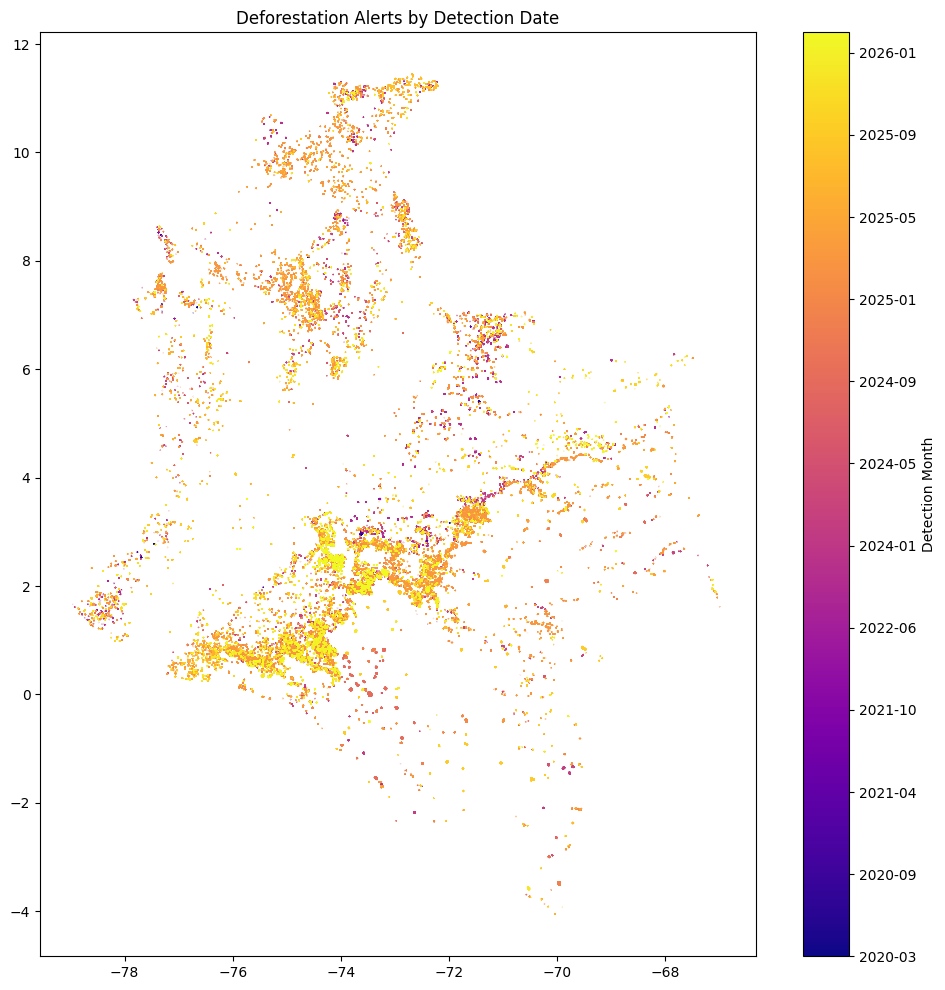

In [9]:
from matplotlib.widgets import Slider
import matplotlib as mpl

# Create a monthly period
gdf["month"] = gdf["datadetec"].dt.to_period("M")

# Chronological list of months
months = sorted(gdf["month"].unique())

# Numeric index for coloring
month_to_idx = {m: i for i, m in enumerate(months)}
gdf["month_idx"] = gdf["month"].map(month_to_idx)

fig, ax = plt.subplots(figsize=(12, 12))


# Colormap
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=0, vmax=len(months)-1)

# Plot boundaries colored by date
gdf.plot(
    ax=ax,
    facecolor="none",          # Only draw the boundaries
    edgecolor=None,
    column="month_idx",         # <-- Color according to this column
    cmap=cmap,
    linewidth=1,
    legend=False               # We'll make our own colorbar
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)

tick_locations = list(range(len(months)))

# Too many labels? show every nth
step = max(1, len(months)//10)

cbar.set_ticks(tick_locations[::step])
cbar.set_ticklabels([str(m) for m in months][::step])
cbar.set_label("Detection Month")

ax.set_title("Deforestation Alerts by Detection Date")
plt.show()